In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import importlib
import dataset
from image_builder import *
from data_prepare import *
import data_fetch
from data_fetch import *
from data_fetch import _download_single, _read_mops_csv

importlib.reload(dataset)
importlib.reload(data_fetch)

<module 'data_fetch' from '/home/iof_314707035/Jasper/Reimage_price_trends/data_fetch.py'>

In [2]:
from dataset import *
import os

START = "1993-01-01"
END = "2019-12-31"
TRAIN_END = "2000-12-31"
SAVE_DIR = "data"
Market = "US_1993_2020"
I = 5
R = 5
CRSP_DATA_DIR = resolve_crsp_data_dir()
print("CRSP data dir:", CRSP_DATA_DIR)

TICKERS, crsp_info = get_crsp_permno_universe(
    crsp_data_dir=CRSP_DATA_DIR,
    start=START,
    end=END,
    return_info=True,
)

print("permno 數量:", len(TICKERS))
display(crsp_info.head())

CRSP data dir: us_stock
permno 數量: 20721


,ticker,permno,first_year,last_year,rows
0,10001,10001,1993,2017,5666
1,10002,10002,1993,2013,3873
2,10003,10003,1993,1995,665
3,10009,10009,1993,2000,1347
4,10010,10010,1993,1995,670


In [ ]:

X_trainval, y_trainval, X_test, y_test, meta = build_research_dataset(
    tickers=TICKERS,
    start=START,
    end=END,
    I=I,
    R=R,
    train_end=TRAIN_END,
    save_dir=SAVE_DIR,
    Market=Market,
    price_source="crsp",
    crsp_data_dir=CRSP_DATA_DIR,
    checkpoint_every=1,
    resume=False,
    process_by="year",
    checkpoint_save_arrays=False,
    year_ticker_chunk_size=1000,
    max_workers=8,
)



Year-based CRSP build: pending years=[1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]

[I5/R5] build year: 1993


year 1993 chunks: 100%|██████████| 21/21 [03:13<00:00,  9.19s/it]


  done year 1993: 333280 images
  Checkpoint saved: 1 tickers done, 333280 images

[I5/R5] build year: 1994


year 1994 chunks: 100%|██████████| 21/21 [04:19<00:00, 12.36s/it]


  done year 1994: 368862 images
  Checkpoint saved: 2 tickers done, 702142 images

[I5/R5] build year: 1995


year 1995 chunks:  48%|████▊     | 10/21 [03:23<03:43, 20.32s/it]


KeyboardInterrupt: 

In [3]:
I = 5
R = 5
Market = "US_1993_2020"

dataset_dir = f"data/training_data/{Market}/I{I}R{R}S{R}_week"

X_trainval = np.load(f"{dataset_dir}/X_trainval.npy")
y_trainval = np.load(f"{dataset_dir}/y_trainval.npy")

X_test = np.load(f"{dataset_dir}/X_test.npy")
y_test = np.load(f"{dataset_dir}/y_test.npy")

meta = pd.read_csv(f"{dataset_dir}/meta.csv")
meta_trainval = pd.read_csv(f"{dataset_dir}/meta_trainval.csv")
meta_test = pd.read_csv(f"{dataset_dir}/meta_test.csv")

print("X_trainval:", X_trainval.shape)
print("y_trainval:", y_trainval.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("meta_trainval:", meta_trainval.shape)
print("meta_test:", meta_test.shape)

display(meta.head())



X_trainval: (3177255, 32, 15)
y_trainval: (3177255,)
X_test: (6192695, 32, 15)
y_test: (6192695,)
meta_trainval: (3177255, 12)
meta_test: (6192695, 12)


,ticker,start_date,date,label_end_date,label,ret,I,R,sample_step,sample_freq,price_source,ending_date
0,10001,1993-01-14,1993-01-22,1993-02-09,0,-0.018170,5,5,5,week,crsp,1993-01-22
1,10001,1993-02-02,1993-02-12,1993-03-01,1,0.054209,5,5,5,week,crsp,1993-02-12
2,10001,1993-02-12,1993-02-26,1993-03-11,1,0.020092,5,5,5,week,crsp,1993-02-26
3,10001,1993-03-08,1993-03-12,1993-03-23,0,-0.052392,5,5,5,week,crsp,1993-03-12
4,10001,1993-03-25,1993-04-08,1993-04-19,1,0.044248,5,5,5,week,crsp,1993-04-08


In [ ]:
import model
importlib.reload(model)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


RUN_SEEDS = list(range(10))
ENSEMBLE_DIR = f"models/{Market}/I{I}R{R}"
EPOCHS = 50
BATCH_SIZE = 256
VAL_RATIO = 0.3

ensemble_results = model.train_resplit_ensemble(
    X_trainval=X_trainval,
    y_trainval=y_trainval,
    I=I,
    R=R,
    seeds=RUN_SEEDS,
    save_dir=ENSEMBLE_DIR,
    Market=Market,
    val_ratio=VAL_RATIO,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=1e-4,
    weight_decay=0,
    device=device,
)


Using device: cuda


ensemble runs:   0%|          | 0/1 [1:04:10<?, ?it/s, seed=0]


KeyboardInterrupt: 

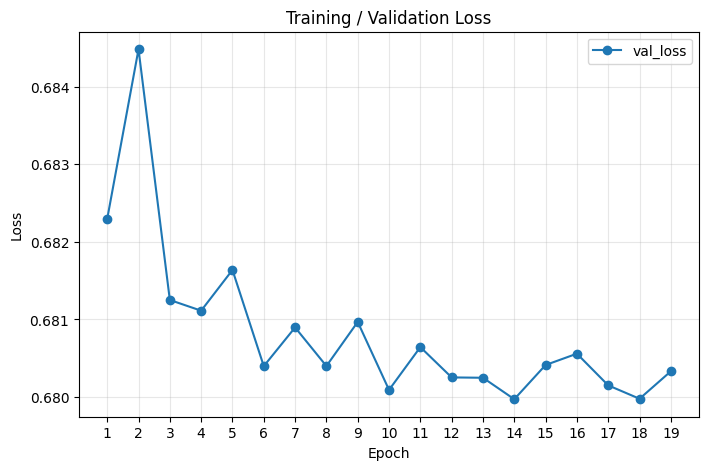

In [ ]:
# import torch
# import pandas as pd
# import matplotlib.pyplot as plt


# result = pd.read_csv("/home/iof_314707035/Jasper/Reimage_price_trends/models/US_1993_2020/I5R5/US_1993_2020_training_history_I5R5_seed0.csv")

# plt.figure(figsize=(8, 5))
# plt.plot(result["epoch"], result["val_loss"], label="val_loss", marker="o")
# plt.xlabel("Epoch")
# plt.xticks(result["epoch"])
# plt.ylabel("Loss")
# plt.title("Training / Validation Loss")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()


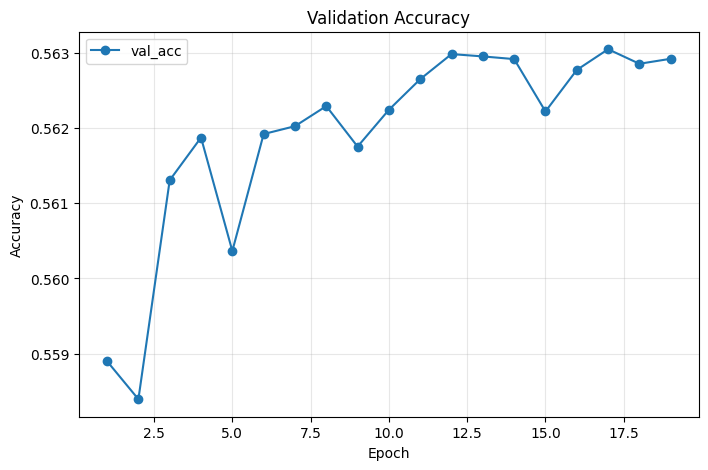

In [ ]:
# plt.figure(figsize=(8, 5))
# plt.plot(result["epoch"], result["val_acc"], label="val_acc", marker="o")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.title("Validation Accuracy")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

# Test

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, accuracy_score, log_loss
import model
import importlib
importlib.reload(model)

root = Path("/home/iof_314707035/Jasper")

# 1. 讀取 test data
market = "US_1993_2020"
dataset_dir = root / "Reimage_price_trends" / "data" / "training_data" / market / "I5R5S5_week"

X_test = np.load(dataset_dir / "X_test.npy")
y_test = np.load(dataset_dir / "y_test.npy")

print(X_test.shape, y_test.shape)


(6192695, 32, 15) (6192695,)


In [5]:
model_dir = root / "Reimage_price_trends" / "models" / "US_1993_2020" / "I5R5"
RUN_SEEDS = list(range(10))
seeds = list(RUN_SEEDS)

summary_frames = []
checkpoint_paths = []
for seed in seeds:
    summary_path = model_dir / f"US_1993_2020_training_summary_I5R5_seed{seed}.csv"
    summary_df = pd.read_csv(summary_path)
    best_path = Path(summary_df.loc[0, "best_path"])
    if not best_path.is_absolute():
        best_path = root / "Reimage_price_trends" / best_path
    checkpoint_paths.append(str(best_path))
    summary_frames.append(summary_df.assign(seed=seed, resolved_best_path=str(best_path)))

ensemble_summary_df = pd.concat(summary_frames, ignore_index=True)
print("ensemble checkpoints:")
for path in checkpoint_paths:
    print(path)


ensemble checkpoints:
/home/iof_314707035/Jasper/Reimage_price_trends/models/US_1993_2020/I5R5/US_1993_2020_best_model_I5R5_seed0.pth
/home/iof_314707035/Jasper/Reimage_price_trends/models/US_1993_2020/I5R5/US_1993_2020_best_model_I5R5_seed1.pth
/home/iof_314707035/Jasper/Reimage_price_trends/models/US_1993_2020/I5R5/US_1993_2020_best_model_I5R5_seed2.pth
/home/iof_314707035/Jasper/Reimage_price_trends/models/US_1993_2020/I5R5/US_1993_2020_best_model_I5R5_seed3.pth
/home/iof_314707035/Jasper/Reimage_price_trends/models/US_1993_2020/I5R5/US_1993_2020_best_model_I5R5_seed4.pth
/home/iof_314707035/Jasper/Reimage_price_trends/models/US_1993_2020/I5R5/US_1993_2020_best_model_I5R5_seed5.pth
/home/iof_314707035/Jasper/Reimage_price_trends/models/US_1993_2020/I5R5/US_1993_2020_best_model_I5R5_seed6.pth
/home/iof_314707035/Jasper/Reimage_price_trends/models/US_1993_2020/I5R5/US_1993_2020_best_model_I5R5_seed7.pth
/home/iof_314707035/Jasper/Reimage_price_trends/models/US_1993_2020/I5R5/US_1993_2

In [ ]:
pred_prob = model.average_ensemble_predictions(
    X_test,
    checkpoint_paths,
    batch_size=256,
    device="cuda"
)

pred_prob = np.asarray(pred_prob).reshape(-1)
pred_label = (pred_prob > 0.5).astype(int)


/home/iof_314707035/miniconda3/envs/reimage-price-trends/lib/python3.11/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.5) - (12.0)
    
  queued_call()


In [7]:
test_mse = mean_squared_error(y_test, pred_prob)
test_acc = accuracy_score(y_test, pred_label)
test_logloss = log_loss(y_test, pred_prob)

print("ensemble checkpoints:", len(checkpoint_paths))
print("test MSE:", test_mse)
print("test accuracy:", test_acc)
print("test logloss:", test_logloss)


ensemble checkpoints: 10
test MSE: 0.25006258487701416
test accuracy: 0.5130649766046892
test logloss: 0.6932843912570316


In [8]:
import pandas as pd
import portfolio_backtest as pb

pred_df = pb.make_prediction_frame(
    meta=meta_test,
    y_true=y_test,
    pred_prob=pred_prob,
    pred_label_threshold=0.5,
)


seed_tag = "seed" + "_".join(str(seed) for seed in seeds)
run_dir = model_dir / f"ensemble_{seed_tag}"
grouped_df, portfolio_returns, summary = pb.run_decile_backtest(
    pred_df,
    n_groups=10,
    R=5,
    output_dir=str(run_dir / "backtest_ensemble_mean_prob"),
    prefix="i5r5_ensemble_mean_prob",
)

summary

,strategy,n_periods,periods_per_year,annualization_method,mean_period_return,period_volatility,annualized_return,annualized_volatility,sharpe,compound_annualized_return,compound_sharpe,cumulative_return,max_drawdown,positive_period_rate
0,long_top_ret,990,52.0,js_cnn,0.009504,0.030222,0.494197,0.217933,2.267659,0.635360,2.267659,7.481625e+03,-0.358761,0.671717
1,short_bottom_ret,990,52.0,js_cnn,0.005109,0.021122,0.265689,0.152310,1.744402,0.303448,1.744402,1.243498e+02,-0.381002,0.575758
2,long_short_ret,990,52.0,js_cnn,0.014613,0.017823,0.759886,0.128527,5.912275,1.126308,5.912275,1.489769e+06,-0.042820,0.867677
